# Scoring by Player Origin - both previous team and hometown

## Dependencies and Setup

In [189]:
import os
import sys
from pathlib import Path
import pandas as pd
import regex as re

import numpy as np
import requests
from bs4 import BeautifulSoup
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties
from matplotlib.offsetbox import OffsetImage
from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import ScalarFormatter
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from PIL import Image

# ======= BASE PATHS =======
try:
    # Works when running as a script
    base_dir = Path(__file__).resolve().parent
except NameError:
    # Fallback for notebooks or interactive mode
    base_dir = Path.cwd()

project_root = base_dir.parent.parent


# ======= DATA FOLDERS =======
temp_folder = project_root / "TEMP"
data_folder = project_root / "data"
roster_folder = data_folder / "player_info"
school_info_folder = data_folder / "school_info"

# ======= IMAGE FOLDERS =======
img_folder = project_root / "images"
logo_folder = img_folder / "logos"
background_folder = img_folder / "background"
plot_folder = project_root / "TEMP" / "IMAGE" / "scoring_origins"

# ======= IMPORT CONFIG =======
import config  # now you can import config.py

# ======= LOAD DATA =======
roster_file = roster_folder / "roster_10_30_25.csv"
roster_df = pd.read_csv(roster_file)
roster_df["Current Team"] = roster_df["Current Team"].replace("RPI", "Rensselaer")

print(roster_df.columns)

school_info_file = school_info_folder / "arena_school_info.csv"
school_info_df = pd.read_csv(school_info_file)

# Check the Config import
# print((config_folder / "config.py").read_text())

Index(['Current Team', 'Last_Name', 'First_Name', 'No', 'Position', 'Yr', 'Ht',
       'Wt', 'DOB', 'Hometown', 'Height_Inches', 'Draft_Year', 'NHL_Team',
       'D_Round', 'Last Team', 'League', 'City', 'State_Province', 'Country'],
      dtype='object')


## Transform the Roster data for easy Merge

In [190]:
# Examine the roster data
# roster_df.head()
# roster_df.info()
# print(roster_df.columns)
# school_info_df.head()

In [191]:
## # Combine First and last name in roster_df to match player_ytd_df

# Clean white space from names
roster_df["First_Name"] = roster_df["First_Name"].str.strip()
roster_df["Last_Name"] = roster_df["Last_Name"].str.strip()
roster_df["Clean_Player"] = roster_df["First_Name"] + " " + roster_df["Last_Name"]
# Strip any leading/trailing whitespace
roster_df["Clean_Player"] = roster_df["Clean_Player"].str.strip()
# Rename Current Team to match player_ytd_df
roster_df = roster_df.rename(columns={"Current Team": "Team"})
# Reorder columns for easier viewing
#Order of columns
# ["No","Team","Clean_Player", "First_Name","Last_Name", 'Position', 'Yr', 'Ht', 'Wt', 'DOB', 'Hometown', 'Height_Inches', 'Draft_Year', 'NHL_Team', 'D_Round', 'Last Team', 'League', 'City', 'State_Province', 'Country']
roster_df = roster_df[["No","Team","Clean_Player", "First_Name","Last_Name", 'Position', 'Yr', 'Ht', 'Wt', 'DOB', 'Hometown', 'Height_Inches', 'Draft_Year', 'NHL_Team', 'D_Round', 'Last Team', 'League', 'City', 'State_Province', 'Country']]    




roster_df.head()

## State_Province Value Counts
check_states = roster_df["State_Province"].value_counts(dropna=False)
check_states


State_Province
Minnesota           217
Ontario             211
British Columbia    124
Alberta             116
New York             98
                   ... 
Delaware              1
Germany               1
JPN                   1
Utah                  1
Okla.                 1
Name: count, Length: 73, dtype: int64

In [192]:
### Roster Modifications to make up for incomplete data ###

### Replace bad values in State_Province column
state_province_corrections = {"Okla.": "Oklahoma", "D.C": "District of Columbia"
}
# Apply state/province corrections
roster_df["State_Province"] = roster_df["State_Province"].replace(state_province_corrections)

### Replace country abbreviations with full country names
country_corrections = {"CYM": "Cayman Islands", "JPN": "Japan", "RUS": "Russia"
}
# Apply country corrections
roster_df["Country"] = roster_df["Country"].replace(country_corrections)

########## HOTFIX FOR BAD LAST_TEAM / LEAGUE DATA ##########
# Correct Adam Valentini - Listed as Canada U18 but that was just a tourney. he actually played in the USHL
roster_df.loc[roster_df["Clean_Player"] == "Adam Valentini", "Last Team"] = "Chicago Steel"
roster_df.loc[roster_df["Clean_Player"] == "Adam Valentini", "League"] = "USHL"

# Correct Tanner Hartman - Listed as NCAA D3 which is screwing up the classification - change that to DIII
roster_df.loc[roster_df["Clean_Player"] == "Tanner Hartman", "League"] = "DIII"

# Correct Justin Solovey - Team Muskegon Lumberjacks, League USHL
roster_df.loc[roster_df["Clean_Player"] == "Justin Solovey", "Last Team"] = "Muskegon Lumberjacks"
roster_df.loc[roster_df["Clean_Player"] == "Justin Solovey", "League"] = "USHL"



# Create List or Dictionary of known players with bad/missing data and their correct last team/league
# Then apply those corrections to the roster_df before classification
corrections = {
    "Anthony Galante": "NAHL",
    "Charles Banquier": "BCHL",
    "Devon Carlstrom": "NAHL",
    "Dominick Campione": "AJHL",
    "Frank Ireland": "NCDC",
    "Graham Harris": "DIII",
    "Johnny Druskinis": "NCAA D1",
    "Jonathan Castagna": "PREP",
    "Joseph Grainda": "NAHL",
    "Kasper Magnussen": "Europe",
    "Maxon Vig": "USHL",
    "Mick Frechette": "PREP",
    "Nicholas Chin-DeGraves": "BCHL",
    "Nick Bernardo": "PREP",
    "Tristan Sarsland": "PREP",
    "Wilson Bjorck": "Europe",
    
}

## Apply corrections to roster_df
for player, league in corrections.items():
    roster_df.loc[roster_df["Clean_Player"] == player, "League"] = league
    







### Connect to database

In [193]:
## Connect to database using the recent_clean_db path from config.py
import sqlite3

#### CONFIG FILE NOTE WORKING AS EXPECTED - MANUAL FIX ####
data_folder = ('../../data/db/')
# filename = '2025_Feb_13_CLEAN.db'
filename = 'Season_YTD.db'
recent_clean_db = data_folder + filename
########### END MANUAL FIX ###########

conn = sqlite3.connect(recent_clean_db)
cursor = conn.cursor()
print("Connected to database:", config.recent_clean_db)


Connected to database: ../../data/db/Season_YTD.db


### Extract and merge the year to date stats
- Issue - the way the player stats ytd table is created it gives credit for games played to everyone, even if they didn't appear in a game
- ultimately I should change the scraping and aggrigation code so a player only gets credit for a game if TOI_sec is > 0

In [194]:
#### Extract and merge the year to date stats ####
player_ytd_query = """
SELECT * FROM player_stats_ytd
"""

player_ytd_df = pd.read_sql_query(player_ytd_query, conn)
# Replace RPI with Rensselaer to match roster_df
player_ytd_df["Team"] = player_ytd_df["Team"].replace("RPI", "Rensselaer")

## print length of DataFrame and columns
print("Player Stats YTD DataFrame shape:", player_ytd_df.shape)
print(player_ytd_df.columns)
# Drop any rows with TOTAL in the Clean_Player column
player_ytd_df = player_ytd_df[~player_ytd_df['Clean_Player'].str.contains('TOTAL', na=False)]

# Check length of DataFrame and columns after drop

print("Player Stats YTD DataFrame shape:", player_ytd_df.shape)
print(player_ytd_df.columns)

# Close the database connection
conn.close()



Player Stats YTD DataFrame shape: (1616, 14)
Index(['Clean_Player', 'Team', 'G', 'A', 'Pts', 'PlusMinus', 'Shots',
       'TOI_sec', 'PIM', 'FOW', 'FOL', 'Games_Played', 'FO%', 'TOI'],
      dtype='object')
Player Stats YTD DataFrame shape: (1616, 14)
Index(['Clean_Player', 'Team', 'G', 'A', 'Pts', 'PlusMinus', 'Shots',
       'TOI_sec', 'PIM', 'FOW', 'FOL', 'Games_Played', 'FO%', 'TOI'],
      dtype='object')


In [195]:
# Make sure name and team columns are stripped of punctuation, strange characters, and whitespace
player_ytd_df["Clean_Player"] = player_ytd_df["Clean_Player"].str.strip()
player_ytd_df["Team"] = player_ytd_df["Team"].str.strip()
roster_df["Clean_Player"] = roster_df["Clean_Player"].str.strip()
roster_df["Team"] = roster_df["Team"].str.strip()
# Remove any hyphens, periods, ect from team names to match
player_ytd_df["Team"] = player_ytd_df["Team"].str.replace(r'[^\w\s]', ' ', regex=True)
roster_df["Team"] = roster_df["Team"].str.replace(r'[^\w\s]', ' ', regex=True)
# QUICK FIX - Standardize team names with double spaces
# If team name column has double spaces, replace with single space
player_ytd_df["Team"] = player_ytd_df["Team"].str.replace('  ', ' ', regex=False)
roster_df["Team"] = roster_df["Team"].str.replace('  ', ' ', regex=False)

## Merge the two DataFrames on Clean_Player and Team
merged_df = pd.merge(
    player_ytd_df,
    roster_df,
    left_on=["Clean_Player", "Team"],
    right_on=["Clean_Player", "Team"],
    how="left"
)

# Shape and info of merged DataFrame
print("Merged DataFrame shape:", merged_df.shape)
# print(merged_df.columns)
# print(merged_df.head())
merged_df.info()



Merged DataFrame shape: (1616, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1616 entries, 0 to 1615
Data columns (total 32 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Clean_Player    1616 non-null   object 
 1   Team            1616 non-null   object 
 2   G               1616 non-null   int64  
 3   A               1616 non-null   int64  
 4   Pts             1616 non-null   int64  
 5   PlusMinus       1616 non-null   int64  
 6   Shots           1616 non-null   int64  
 7   TOI_sec         1616 non-null   int64  
 8   PIM             1616 non-null   int64  
 9   FOW             1616 non-null   float64
 10  FOL             1616 non-null   float64
 11  Games_Played    1616 non-null   int64  
 12  FO%             1616 non-null   float64
 13  TOI             1616 non-null   object 
 14  No              1615 non-null   float64
 15  First_Name      1615 non-null   object 
 16  Last_Name       1615 non-null   object 
 17

### NEED TO DEAL WITH THIS WEIRD ONE EDGE CASE

In [196]:
## Export merged DataFrame to CSV for examination
# output_file = "../../TEMP/merged_player_stats_roster_test_1.csv"

## Show me a random selection of ten rows that didn't match for merge
## ie no current team, last name, ect
missing_team_df = merged_df[merged_df["First_Name"].isnull()]

missing_team_df


,Clean_Player,Team,G,A,Pts,PlusMinus,Shots,TOI_sec,PIM,FOW,...,Hometown,Height_Inches,Draft_Year,NHL_Team,D_Round,Last Team,League,City,State_Province,Country
1092,Maxon Vig,Bemidji State,2,1,3,12,14,15907,10,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning and Validation

### Filter out players with no TOI and goalies
- Remove players that haven't appeared in a game at all this year (TOI_sec = 0)
    -can't depend on YTD stats games played until we fix the scraping code
- Filter out goaltenders as non skaters - looking at offensive production so goalies are irrelivant (despite the assists they may get from time to time)



In [197]:
## Print Value COunt of Position column
# print(merged_df['Position'].value_counts())

In [198]:
### Print dataframe stats for to keep track of filtering steps
original_count = merged_df.shape[0]
print("Merged DataFrame shape before filtering:", merged_df.shape)

### Filter out players with no TOI and goalies
# Remove players that haven't appeared in a game at all this year (TOI_sec = 0)
# Remove any Rows where TOI_sec is 0 or NaN - These are goalies or players with no time on ice
merged_df = merged_df[(merged_df["TOI_sec"] > 0) & (~merged_df["TOI_sec"].isna())]
first_step_count = merged_df.shape[0]

## Check the shape after filtering
print("Merged DataFrame shape after filtering TOI_sec > 0:", merged_df.shape)
# Number of players removed
print("Players removed after filtering TOI_sec > 0:", original_count - first_step_count)

### DO NOT NEED TO FILTER FOR GOALIES BECAUSE PLAYER_YTD_STATS TABLE ONLY HAS TOI FOR SKATERS
# Filter out goaltenders as non skaters - looking at offensive production so goalies are irrelivant (despite the assists they may get from time to time)
# Strip any whitespace from Position column
# merged_df["Position"] = merged_df["Position"].str.strip()
# merged_df = merged_df[merged_df["Position"] != "Goaltenders"]
# no_goalie_count = merged_df.shape[0]
## Check the shape after filtering
# print("Merged DataFrame shape after filtering out Goalies:", merged_df.shape)
# # Number of players removed
# print("Players removed by filtering out Goalies:", first_step_count - no_goalie_count)

Merged DataFrame shape before filtering: (1616, 32)
Merged DataFrame shape after filtering TOI_sec > 0: (1475, 32)
Players removed after filtering TOI_sec > 0: 141


In [199]:
# merged_df.columns

## Quick Explore of Origin Data

In [200]:
## Value count of 'League' column
# print(merged_df['League'].value_counts())

# ### Country value counts
# print(merged_df['Country'].value_counts())

# # Check for any players that have null or 0 TOI but have Games Played > 0
# null_toi_df = merged_df[(merged_df["TOI_sec"].isnull()) | (merged_df["TOI_sec"] == 0) & (merged_df["Games_Played"] > 0)]
# null_toi_df




In [201]:
# Correct Maxon Vig - Team Cedar Rapids RoughRiders, League USHL
## Couldn't do it before because he was not in original roster_df but now he is in merged_df
merged_df.loc[merged_df["Clean_Player"] == "Maxon Vig", "Last Team"] = "Cedar Rapids RoughRiders"
merged_df.loc[merged_df["Clean_Player"] == "Maxon Vig", "League"] = "USHL"

### Clean and Classify Previous Team / League columns
- put into the same bins as used on the Team Construction Visual
- Copied code from there with a few changes made based on feedback / missed classifications 

In [202]:
### Reusing League and Team Classification function and libraries from team_construction_visual_workbook import classify_previous_team, classify_previous_league

# ----------------------------
# 1) Rename merged_df to df for easier to fit in with existing code
# -----------------------------
df = merged_df.copy()

# -----------------------------
# 2) Classification helpers
# -----------------------------
def _norm_set(strings):
    return { _norm(s) for s in strings }

def _norm(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip().upper()
    s = re.sub(r"[.\u2010-\u2015\-–—]+", " ", s)  # unify hyphen-like chars to space
    s = re.sub(r"\s+", " ", s).strip()
    return s

def _norm_set(strings):
    return { _norm(s) for s in strings }

NTDP_TEAM_HINTS_RAW = (
    "USA U 18", "US U 18", "USA U18", "US U18",
    "USA U 17", "US U 17", "USA U17", "US U17",
    "NTDP", "USNTDP", "US NATIONAL TEAM", "US DEV PROGRAM", "US DEVELOPMENT PROGRAM"
)
NTDP_LEAGUE_HINTS_RAW = ("NTDP",)

D1_CONFS_RAW = {"ECAC","CCHA","NCHC","HEA","B10","AHA","INDEPENDENTS","D I IND","NCAA"}

CJHL_LEAGUES_RAW = {"BCHL","AJHL","SJHL","OJHL", "MJHL", "CCHL","MHL", "MJAHL"}

US_TIER1_RAW = {"USHL"}
US_TIER2_RAW = {"NAHL","NCDC"}
US_OTHER_RAW  = {"USPHL","NA3HL", "PREP", "PHC", "USHS", "CISAA", "DIII", "D-III"}

CHL_RAW = {"OHL","WHL","QMJHL"}

EURO_HINTS_RAW = {
    "J20 NATIONELL","J18 REGION","U20 SM SARJA","U18","U20","SM SARJA",
    "SHL","ICEHL","ALPSHL","LIIGA","MHL RUSSIA","KHL, ICEHL","KHL","DEL", "EC-KAC",
}

EURO_TEAM_HINTS_RAW = {
    "KalPa U20", "Frölunda HC", "Malmo", "Jokerit U20", "U20 SM Sarja-Pelicans",
    "Tappara J20", "Djurgårdens IF", "Leksands IF",
}

RUSSIAN_MHL_TEAM_HINTS_RAW = (
    "KRASNAYA","LOKO","MOSKVA","MOSCOW","ST PETERSBURG","SKA","LOKOMOTIV",
    "DMITROV","CHELYABINSK","OMSK","NOVOSIBIRSK","MAGNITOGORSK","NIZHNY","YAROSLAVL",
)

# Normalize them
NTDP_TEAM_HINTS       = _norm_set(NTDP_TEAM_HINTS_RAW)
NTDP_LEAGUE_HINTS     = _norm_set(NTDP_LEAGUE_HINTS_RAW)
D1_CONFS              = _norm_set(D1_CONFS_RAW)
CJHL_LEAGUES          = _norm_set(CJHL_LEAGUES_RAW)
US_TIER1              = _norm_set(US_TIER1_RAW)
US_TIER2              = _norm_set(US_TIER2_RAW)
US_OTHER              = _norm_set(US_OTHER_RAW)
CHL                   = _norm_set(CHL_RAW)
EURO_HINTS            = _norm_set(EURO_HINTS_RAW)
EURO_TEAM_HINTS       = _norm_set(EURO_TEAM_HINTS_RAW)
RUSSIAN_MHL_TEAM_HINTS = _norm_set(RUSSIAN_MHL_TEAM_HINTS_RAW)

PRO_HINTS = ("AHL","ECHL")

BIN_ORDER = [
    "NTDP",
    "USHL (non‑NTDP)",
    "NAHL/NCDC",
    "US (DIII/Prep/Other)",
    "CHL (Major Junior)",
    "CJHL (Canadian Jr A)",
    "U SPORTS",
    "Europe",
    "NCAA D1 Transfers",
    "Pro (AHL/ECHL/Other)",
    "Other/Various/Unknown"
    
]

COLOR_MAP = {
    "NTDP": "#0057B8",
    "USHL (non‑NTDP)": "#1E90FF",
    "NAHL/NCDC": "#63B8FF",
    "US (DIII/Prep/Other)": "#B0E2FF",
    "CHL (Major Junior)": "#B22222",
    "CJHL (Canadian Jr A)": "#FF7F7F",
    "U SPORTS": "#FADBD8",
    "Europe": "#F0E130",
    "NCAA D1 Transfers": "#696969",
    "Pro (AHL/ECHL/Other)": "#000000",
    "Other/Various/Unknown": "#A9A9A9"
}

def classify_prev_bin(last_team: str, league: str) -> str:
    t = _norm(last_team)
    l = _norm(league)

    # NTDP carve-out first
    if any(h in t for h in NTDP_TEAM_HINTS) or any(h == l for h in NTDP_LEAGUE_HINTS):
        return "NTDP"

    # D3/Prep -> Other
    if l in US_OTHER:
        return "US (DIII/Prep/Other)"

    # NCAA D1 transfers
    if (l in D1_CONFS) or ("NCAA" in l and l != ""):
        return "NCAA D1 Transfers"

    # U SPORTS
    if l in {"USPORTS", "U SPORTS"}:
        return "U SPORTS"

    # CHL
    if l in CHL:
        return "CHL (Major Junior)"

    # MHL ambiguity
    if l == "MHL":
        if any(k in t for k in RUSSIAN_MHL_TEAM_HINTS):
            return "Europe"
        else:
            return "CJHL (Canadian Jr A)"

    # CJHL
    if l in CJHL_LEAGUES:
        return "CJHL (Canadian Jr A)"



    # US juniors
    if l in US_TIER1:
        return "USHL (non‑NTDP)"
    if l in US_TIER2:
        return "NAHL/NCDC"
    
    # Pro leagues
    if any(h in l for h in PRO_HINTS):
        return "Pro (AHL/ECHL/Other)"

    # Europe consolidated
    if l in EURO_HINTS:
        return "Europe"
    if t in EURO_TEAM_HINTS:
        return "Europe"




    # Fallbacks/Unknown
    # if l == "" or pd.isna(league):
    #     return "Other/Various/Unknown"
    
    if "U SPORTS" in t:
        return "U SPORTS"
    if "IF Sundsvall" in t:  # edge case
        return "Europe"


    return "Other/Various/Unknown"


# Apply classification to the raw roster
df["Prev_League_Bin"] = df.apply(lambda r: classify_prev_bin(r.get("Last Team", np.nan),
                                                             r.get("League", np.nan)), axis=1)
df["Prev_League_Bin"] = pd.Categorical(df["Prev_League_Bin"], categories=BIN_ORDER, ordered=True)

# Save classified to temp_folder
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# out_file = os.path.join(temp_folder, f"roster_classified_{timestamp}.csv")
# df.to_csv(out_file, index=False)


# show quick counts
overall_counts = (df["Prev_League_Bin"]
                  .value_counts(dropna=False)
                  .reindex(BIN_ORDER)
                  .fillna(0).astype(int))

print("Overall Counts by Prev_League_Bin")
print(overall_counts.reset_index().rename(columns={"index":"Bin","Prev_League_Bin":"Count"}))

Overall Counts by Prev_League_Bin
                    Count  count
0                    NTDP     41
1         USHL (non‑NTDP)    442
2               NAHL/NCDC    204
3    US (DIII/Prep/Other)     11
4      CHL (Major Junior)    148
5    CJHL (Canadian Jr A)    322
6                U SPORTS     34
7                  Europe     24
8       NCAA D1 Transfers    243
9    Pro (AHL/ECHL/Other)      5
10  Other/Various/Unknown      1


In [203]:
## Show The Other/Various/Unknown players
other_unknown_df = df[df["Prev_League_Bin"] == "Other/Various/Unknown"]
other_unknown_df = other_unknown_df[["Clean_Player", "Team", "Last Team", "League", "Prev_League_Bin" ]]
# other_unknown_df

### Generate table of the number of players on each team

In [204]:
### Create a table of the number of players on each team from the various leagues
team_league_counts = (df
                      .groupby(["Team", "Prev_League_Bin"])
                      .size()
                      .unstack(fill_value=0)
                      .reindex(columns=BIN_ORDER, fill_value=0)
                     )  

# Reorder so CHL is first column after Team
cols = team_league_counts.columns.tolist()
cols = cols[-6:] + cols[:-1]  # Move last column to first position
team_league_counts = team_league_counts[cols]



# team_league_counts                  

C:\Users\jbanc\AppData\Local\Temp\ipykernel_17396\3039452061.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Team", "Prev_League_Bin"])


## Aggrigate 2025-26 Stats using the new class bins

In [205]:
### Group by Prev_League_Bin and aggregate stats (G, A, Pts, PlusMinus, Shots, TOI_sec, PIM)

agg_stats = {
    "Games_Played": "sum",
    "G": "sum",
    "A": "sum",
    "Pts": "sum",
    "PlusMinus": "sum",
    "Shots": "sum",
    "TOI_sec": "sum",
    "PIM": "sum",
}
agg_df = df.groupby("Prev_League_Bin").agg(agg_stats).reset_index()
# # creat column for count of players in each bin
# agg_df["Player_Count"] = df["Prev_League_Bin"].value_counts().reindex(agg_df["Prev_League_Bin"]).values
# # Create AVG games played per player column
# agg_df["Avg_Games Played"] = agg_df["Games_Played"] / agg_df["Player_Count"]

# # Reorder Columns to put player_count right after Prev_League_Bin
# agg_df = agg_df[["Prev_League_Bin", "Player_Count", "Games_Played", "Avg_Games Played"] + list(agg_stats.keys())]


agg_df

C:\Users\jbanc\AppData\Local\Temp\ipykernel_17396\1377335929.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = df.groupby("Prev_League_Bin").agg(agg_stats).reset_index()


,Prev_League_Bin,Games_Played,G,A,Pts,PlusMinus,Shots,TOI_sec,PIM
0,NTDP,507,123,168,291,42,944,501782,440
1,USHL (non‑NTDP),4753,743,1319,2062,224,7669,4480131,2598
2,NAHL/NCDC,1745,183,339,522,-250,2241,1453579,844
3,US (DIII/Prep/Other),109,28,27,55,6,216,104940,72
4,CHL (Major Junior),1670,290,464,754,-53,2879,1544309,1069
5,CJHL (Canadian Jr A),2995,403,687,1090,-120,4172,2564893,1431
6,U SPORTS,371,70,124,194,-17,607,356445,286
7,Europe,231,44,62,106,11,314,199491,105
8,NCAA D1 Transfers,2814,481,801,1282,-36,4796,2754727,1625
9,Pro (AHL/ECHL/Other),62,14,27,41,12,106,72312,65


In [206]:
## Get count of players in each Prev_League_Bin
player_counts = (df["Prev_League_Bin"]
                  .value_counts(dropna=False)
                  .reindex(BIN_ORDER)
                  .fillna(0).astype(int))

# print("Player Counts by Prev_League_Bin")
# print(player_counts.reset_index().rename(columns={"index":"Bin","Prev_League_Bin":" Count"}))

In [207]:
### Divide aggregated stats by player counts to get per player averages
for stat in agg_stats.keys():
    agg_df[stat + "_per_player"] = agg_df[stat] / player_counts.values
# agg_df

## Use the Games_Played column to get per game averages for all stats
for stat in agg_stats.keys():
    agg_df[stat + "_per_game"] = agg_df[stat] / agg_df["Games_Played"]

#### Calulate per 60 minutes stats for each aggregated stat
for stat in agg_stats.keys():
    agg_df[stat + "_per_60min"] = (agg_df[stat] / agg_df["TOI_sec"]) * 3600

In [208]:
# #### Calulate per 60 minutes stats for each aggregated stat
# for stat in agg_stats.keys():
#     agg_df[stat + "_per_60min"] = (agg_df[stat] / (agg_df["TOI_sec"]) * 3600)


In [209]:
# # create column for count of players in each bin
agg_df["Player_Count"] = df["Prev_League_Bin"].value_counts().reindex(agg_df["Prev_League_Bin"]).values
# # Create AVG games played per player column
agg_df["Avg_Games Played"] = agg_df["Games_Played"] / agg_df["Player_Count"]

# Move Player_Count column to be right after Prev_League_Bin and Avg_Games Played
cols = agg_df.columns.tolist()
cols.insert(1, cols.pop(cols.index("Player_Count")))
cols.insert(3, cols.pop(cols.index("Avg_Games Played")))
agg_df = agg_df[cols]

In [210]:
### Examine the final aggregated DataFrame
agg_df.info()
agg_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Prev_League_Bin          11 non-null     category
 1   Player_Count             11 non-null     int64   
 2   Games_Played             11 non-null     int64   
 3   Avg_Games Played         11 non-null     float64 
 4   G                        11 non-null     int64   
 5   A                        11 non-null     int64   
 6   Pts                      11 non-null     int64   
 7   PlusMinus                11 non-null     int64   
 8   Shots                    11 non-null     int64   
 9   TOI_sec                  11 non-null     int64   
 10  PIM                      11 non-null     int64   
 11  Games_Played_per_player  11 non-null     float64 
 12  G_per_player             11 non-null     float64 
 13  A_per_player             11 non-null     float64 
 14  Pts_per_play

,Prev_League_Bin,Player_Count,Games_Played,Avg_Games Played,G,A,Pts,PlusMinus,Shots,TOI_sec,...,TOI_sec_per_game,PIM_per_game,Games_Played_per_60min,G_per_60min,A_per_60min,Pts_per_60min,PlusMinus_per_60min,Shots_per_60min,TOI_sec_per_60min,PIM_per_60min
0,NTDP,41,507,12.365854,123,168,291,42,944,501782,...,989.708087,0.867850,3.637436,0.882455,1.205304,2.087759,0.301326,6.772662,3600.0,3.156749
1,USHL (non‑NTDP),442,4753,10.753394,743,1319,2062,224,7669,4480131,...,942.590154,0.546602,3.819263,0.597036,1.059880,1.656916,0.179995,6.162409,3600.0,2.087618
2,NAHL/NCDC,204,1745,8.553922,183,339,522,-250,2241,1453579,...,832.996562,0.483668,4.321747,0.453226,0.839583,1.292809,-0.619161,5.550163,3600.0,2.090289
3,US (DIII/Prep/Other),11,109,9.909091,28,27,55,6,216,104940,...,962.752294,0.660550,3.739280,0.960549,0.926244,1.886792,0.205832,7.409949,3600.0,2.469983
4,CHL (Major Junior),148,1670,11.283784,290,464,754,-53,2879,1544309,...,924.735928,0.640120,3.893003,0.676031,1.081649,1.757679,-0.123550,6.711351,3600.0,2.491988
5,CJHL (Canadian Jr A),322,2995,9.301242,403,687,1090,-120,4172,2564893,...,856.391653,0.477796,4.203684,0.565638,0.964251,1.529888,-0.168428,5.855683,3600.0,2.008505
6,U SPORTS,34,371,10.911765,70,124,194,-17,607,356445,...,960.768194,0.770889,3.747002,0.706981,1.252367,1.959349,-0.171695,6.130539,3600.0,2.888524
7,Europe,24,231,9.625000,44,62,106,11,314,199491,...,863.597403,0.454545,4.168609,0.794021,1.118847,1.912868,0.198505,5.666421,3600.0,1.894822
8,NCAA D1 Transfers,243,2814,11.580247,481,801,1282,-36,4796,2754727,...,978.936389,0.577470,3.677461,0.628592,1.046782,1.675375,-0.047046,6.267627,3600.0,2.123622
9,Pro (AHL/ECHL/Other),5,62,12.400000,14,27,41,12,106,72312,...,1166.322581,1.048387,3.086625,0.696980,1.344175,2.041155,0.597411,5.277132,3600.0,3.235977


## Load The Cleaned Data from 2024-25 Season

In [211]:
## Path to folder with clean 24-25 Season Roster and Stats Data
data_folder = ('../../data/player_info/24_25_season/')
# Print List of files in data_folder
# print(os.listdir(data_folder))

### Finalized Merged Table is 2024_25_Player_Stats_with_Origins_NEW.csv
# Load the finalized merged table
final_merged_file = os.path.join(data_folder, '2024_25_Player_Stats_with_Origins_NEW.csv')
merged_24_25_df = pd.read_csv(final_merged_file)
merged_24_25_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 33 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Clean_Player     1581 non-null   object 
 1   Team             1581 non-null   object 
 2   G                1581 non-null   int64  
 3   A                1581 non-null   int64  
 4   Pts              1581 non-null   int64  
 5   plus_minus       1581 non-null   int64  
 6   Sh               1581 non-null   int64  
 7   TOI_sec          1581 non-null   int64  
 8   PIM              1581 non-null   int64  
 9   FOW              1581 non-null   int64  
 10  FOL              1581 non-null   int64  
 11  Games_Played     1581 non-null   int64  
 12  FO%              1032 non-null   float64
 13  TOI              1581 non-null   object 
 14  No               1571 non-null   float64
 15  First_Name       1571 non-null   object 
 16  Last_Name        1571 non-null   object 
 17  Position      

In [212]:
# Reaname columns Sh to Shots and to match those in 25-26 merged_df
merged_24_25_df = merged_24_25_df.rename(columns={
    "Sh": "Shots",
    "plus_minus": "PlusMinus"
})

### Do the same aggrigation on the 24-25 season data as done above for 25-26 season data
agg_24_25_stats = {
    "Games_Played": "sum",
    "G": "sum",
    "A": "sum",
    "Pts": "sum",
    "PlusMinus": "sum",
    "Shots": "sum",
    "TOI_sec": "sum",
    "PIM": "sum",
}

agg_24_25_df = merged_24_25_df.groupby("Prev_League_Bin").agg(agg_24_25_stats).reset_index()
# # creat column for count of players in each bin
agg_24_25_df["Player_Count"] = merged_24_25_df["Prev_League_Bin"].value_counts().reindex(agg_24_25_df["Prev_League_Bin"]).values
# # Create AVG games played per player column
agg_24_25_df["Avg_Games Played"] = agg_24_25_df["Games_Played"] / agg_24_25_df["Player_Count"]

## Calculate per player averages for 24-25 aggregated stats
for stat in agg_24_25_stats.keys():
    agg_24_25_df[stat + "_per_player"] = agg_24_25_df[stat] / agg_24_25_df["Player_Count"]
# # Calculate per game averages for 24-25 aggregated stats
for stat in agg_24_25_stats.keys():
    agg_24_25_df[stat + "_per_game"] = agg_24_25_df[stat] / agg_24_25_df["Games_Played"]
# # Calculate per 60 minutes averages for 24-25 aggregated stats
for stat in agg_24_25_stats.keys():
    agg_24_25_df[stat + "_per_60min"] = (agg_24_25_df[stat] / agg_24_25_df["TOI_sec"]) * 3600

agg_24_25_df

,Prev_League_Bin,Games_Played,G,A,Pts,PlusMinus,Shots,TOI_sec,PIM,Player_Count,...,TOI_sec_per_game,PIM_per_game,Games_Played_per_60min,G_per_60min,A_per_60min,Pts_per_60min,PlusMinus_per_60min,Shots_per_60min,TOI_sec_per_60min,PIM_per_60min
0,CJHL (Canadian Jr A),9258,1228,2071,3299,-438,13052,8234176,4019,365,...,889.411968,0.434111,4.047618,0.536884,0.905446,1.442330,-0.191495,5.706363,3600.0,1.757116
1,Europe,878,120,221,341,-25,1145,792803,268,34,...,902.964692,0.305239,3.986867,0.544902,1.003528,1.548430,-0.113521,5.199274,3600.0,1.216948
2,NAHL/NCDC,6362,666,1265,1931,-594,8490,5444561,2668,276,...,855.793933,0.419365,4.206620,0.440366,0.836431,1.276797,-0.392759,5.613676,3600.0,1.764109
3,NCAA D1 Transfers,11750,1936,3087,5023,-168,19135,11289308,6117,402,...,960.792170,0.520596,3.746908,0.617363,0.984400,1.601763,-0.053573,6.101880,3600.0,1.950624
4,NTDP,1501,343,575,918,203,3054,1608469,1041,45,...,1071.598268,0.693538,3.359468,0.767687,1.286938,2.054625,0.454345,6.835320,3600.0,2.329917
5,US (DIII/Prep/Other),367,49,81,130,2,475,316406,126,16,...,862.141689,0.343324,4.175648,0.557512,0.921601,1.479112,0.022756,5.404449,3600.0,1.433601
6,USHL (non‑NTDP),14243,2295,3934,6229,599,23471,13876782,6983,443,...,974.287861,0.490276,3.695007,0.595383,1.020582,1.615965,0.155396,6.088991,3600.0,1.811573


## Visualizations Start
- data transformation is looking good to this point. SHould have a few diff. interesting views

- Should I use stacked bars witht he country bins and color grtadiant within?
- Should come up a good visual for the number of games played by each bin of players

### Settings - Colors, order, ect

In [213]:
BIN_ORDER = [
    "CHL (Major Junior)",
    "CJHL (Canadian Jr A)",
    "U SPORTS",
    "Europe",
    "Pro (AHL/ECHL/Other)",
    "NTDP",
    "USHL (non‑NTDP)",
    "NAHL/NCDC",
    "US (DIII/Prep/Other)",

    
    "NCAA D1 Transfers",
    
    "Other/Various/Unknown"
]

COLOR_MAP = {
    "CHL (Major Junior)": "#B22222",
    "CJHL (Canadian Jr A)": "#FF7F7F",
    "U SPORTS": "#FADBD8",
    "Europe": "#F0E130",
    "Pro (AHL/ECHL/Other)": "#2B2B2B",
    "NTDP": "#0057B8",
    "USHL (non‑NTDP)": "#1E90FF",
    "NAHL/NCDC": "#63B8FF",
    "US (DIII/Prep/Other)": "#B0E2FF",
    
    
    "NCAA D1 Transfers": "#696969",
    
    "Other/Various/Unknown": "#A9A9A9"
}


bin_color_mapping = {bin_name: COLOR_MAP[bin_name] for bin_name in BIN_ORDER}

### New Viz - Mon 11-24

In [214]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Reuse your BIN_ORDER and bin_color_mapping from before
# BIN_ORDER = [...]
# bin_color_mapping = {...}

def make_autopct(values, label_mode="percent", min_pct=0.05, raw_decimals=3):
    """
    Returns an autopct function for plt.pie that:
    - Hides labels below min_pct of the donut
    - Shows percentage or raw metric depending on label_mode
    """
    values = np.array(values, dtype=float)
    total = values.sum()

    def autopct(pct):
        frac = pct / 100.0
        if total <= 0 or frac < min_pct:
            return ""
        if label_mode == "percent":
            return f"{pct:.1f}%"
        elif label_mode == "raw":
            val = frac * total
            return f"{val:.{raw_decimals}f}"
        else:
            return ""

    return autopct


# Caption to use in the center of donuts for different metrics
METRIC_CAPTION_MAP = {
    "Player_Count": "Total Players",
    "Games_Played": "Total Games",
    "G": "Total Goals",
    "A": "Total Assists",
    "Pts": "Total Points",
    "PlusMinus": "Total Plus/Minus",
    "Shots": "Total Shots",
    "TOI_sec": "Total TOI (sec)",
    "PIM": "Total PIM",
    "G_per_player": "Goals Per Player",
    "A_per_player": "Assists Per Player",
    "Pts_per_player": "Points Per Player",
    "Shots_per_player": "Shots Per Player",
    "PIM_per_player": "Penalty Minutes Per Player",
    "G_per_game": "Goals Per Game",
    "A_per_game": "Assists Per Game",
    "Pts_per_game": "Points Per Game",
    "Shots_per_game": "Shots Per Game",
    "PIM_per_game": "PIM Per Game",
    
    "G_per_60min": "Goals Per 60",
    "A_per_60min": "Assists Per 60",
    "Pts_per_60min": "Points Per 60",
    "Shots_per_60min": "Shots Per 60",
    "PIM_per_60min": "PIM Per 60",
    # add more as needed
}

def get_metric_caption(metric: str) -> str:
    """
    Get a friendly caption for the metric to use in the center of the donut.
    Falls back to a title-cased version of the column name.
    """
    if metric in METRIC_CAPTION_MAP:
        return METRIC_CAPTION_MAP[metric]
    # generic fallback
    return metric.replace("_", " ").title()


In [215]:
def plot_origin_donuts(
    df_prev_agg,
    df_current_agg,
    metric="G_per_game",
    metric_label=None,
    title="Statistics by Previous League",
    prev_label="2024–25\nFull Season",
    current_label="2025–26\nSeason to Date",
    bin_order=BIN_ORDER,
    bin_color_mapping=bin_color_mapping,
    label_mode="percent",   # "percent", "raw", or None
    raw_decimals=2,
    min_pct_for_label=0.05, # hide wedges <5% of donut
    font_prop=None,
    data_source_text=None,
    signature_text=None,
    figsize=(9, 9),
    center_value_decimals=2,
):
    # ---- 1. Basic checks ----
    if metric not in df_prev_agg.columns:
        raise ValueError(
            f"Metric '{metric}' not found in previous-season table.\n"
            f"Available columns include (prev): {', '.join(df_prev_agg.columns)}"
        )
    if metric not in df_current_agg.columns:
        raise ValueError(
            f"Metric '{metric}' not found in current-season table.\n"
            f"Available columns include (current): {', '.join(df_current_agg.columns)}"
        )

    if metric_label is None:
        metric_label = metric.replace("_", " ")

    # ---- 2. Align data on bins and filter out bins that are zero in both ----
    prev_series = df_prev_agg.set_index("Prev_League_Bin")[metric]
    curr_series = df_current_agg.set_index("Prev_League_Bin")[metric]

    prev_vals = []
    curr_vals = []
    bins_in_use = []

    for b in bin_order:
        v_prev = float(prev_series.get(b, 0.0))
        v_curr = float(curr_series.get(b, 0.0))
        if (v_prev > 0) or (v_curr > 0):
            bins_in_use.append(b)
            prev_vals.append(v_prev)
            curr_vals.append(v_curr)

    prev_vals = np.array(prev_vals, dtype=float)
    curr_vals = np.array(curr_vals, dtype=float)

    # ---- 3. Figure + title ----
    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=figsize)

    if font_prop is not None:
        fig.suptitle(title, fontproperties=font_prop, fontsize=18, y=0.97)
    else:
        fig.suptitle(title, fontsize=18, y=0.97)

    # Make the donut axes fill more of the frame but leave room on the left
    # [left, bottom, width, height] in figure coordinates (0–1)
    ax_top.set_position([0.12, 0.57, 0.76, 0.35])   # upper donut
    ax_bot.set_position([0.12, 0.25, 0.76, 0.35])   # lower donut


    colors = [bin_color_mapping[b] for b in bins_in_use]
    wedgeprops = {"width": 0.65, "edgecolor": "white"}  # nice chunky ring

    # ---- 4. Top donut (previous season) ----
    autopct_prev = make_autopct(
        prev_vals,
        label_mode=label_mode,
        min_pct=min_pct_for_label,
        raw_decimals=raw_decimals,
    )

    wedges1, _texts1, _autotexts1 = ax_top.pie(
        prev_vals,
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops={"width": 0.65, "edgecolor": "white"},   # THICKER RING
        autopct=autopct_prev,
        pctdistance=0.78,
    )
    ax_top.set(aspect="equal")

    # Rotated label to the left of the top donut
    label_x = -0.03
    label_y = 0.5
    ax_top.text(
        label_x, label_y,
        prev_label,
        ha="center", va="center",
        rotation=90,
        fontsize=13,
        fontproperties=font_prop,
        transform=ax_top.transAxes,
    )

    # ---- Center text for previous season ----
    total_prev = prev_vals.sum()
    caption = get_metric_caption(metric)
    center_text_prev = f"{caption}:\n{total_prev:,.{center_value_decimals}f}"
    if np.isclose(total_prev, round(total_prev)):
        center_text_prev = f"{caption}:\n{int(round(total_prev)):,}"

    ax_top.text(
        0.0, 0.0, center_text_prev,
        ha="center", va="center",
        fontsize=12,
        fontproperties=font_prop,
    )

    # ---- 5. Bottom donut (current season) ----
    autopct_curr = make_autopct(
        curr_vals,
        label_mode=label_mode,
        min_pct=min_pct_for_label,
        raw_decimals=raw_decimals,
    )

    wedges2, _texts2, _autotexts2 = ax_bot.pie(
        curr_vals,
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops={"width": 0.65, "edgecolor": "white"},
        autopct=autopct_curr,
        pctdistance=0.78,
    )
    ax_bot.set(aspect="equal")

    # Rotated label to the left
    ax_bot.text(
        label_x, label_y,
        current_label,
        ha="center", va="center",
        rotation=90,
        fontsize=13,
        fontproperties=font_prop,
        transform=ax_bot.transAxes,
    )

    # ---- Center text for current season ----
    total_curr = curr_vals.sum()
    center_text_curr = f"{caption}:\n{total_curr:,.{center_value_decimals}f}"
    if np.isclose(total_curr, round(total_curr)):
        center_text_curr = f"{caption}:\n{int(round(total_curr)):,}"

    ax_bot.text(
        0.0, 0.0, center_text_curr,
        ha="center", va="center",
        fontsize=12,
        fontproperties=font_prop,
    )



    # ---- 6. Legend along the bottom in two rows ----
    import math
    import matplotlib.patches as mpatches

    handles = [
        mpatches.Patch(color=bin_color_mapping[b], label=b) for b in bins_in_use
    ]

    n = len(handles)
    cols = math.ceil(n / 5)  # two rows => ceil(n/2) columns

    fig.legend(
        handles=handles,
        title="Previous League",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.13),
        ncol=cols,
        frameon=False,
        fontsize=8,
        title_fontsize=9,
        handlelength=1.6,
        columnspacing=1.2,
        labelspacing=0.8,
    )

    # ---- 7. Footnotes (data source + signature) ----
    if data_source_text:
        fig.text(
            0.5,
            0.08,
            data_source_text,
            ha="center",
            va="center",
            fontsize=8,
        )
    if signature_text:
        fig.text(
            0.5,
            0.05,
            signature_text,
            ha="center",
            va="center",
            fontsize=7.5,
            alpha=0.85,
        )

    return fig


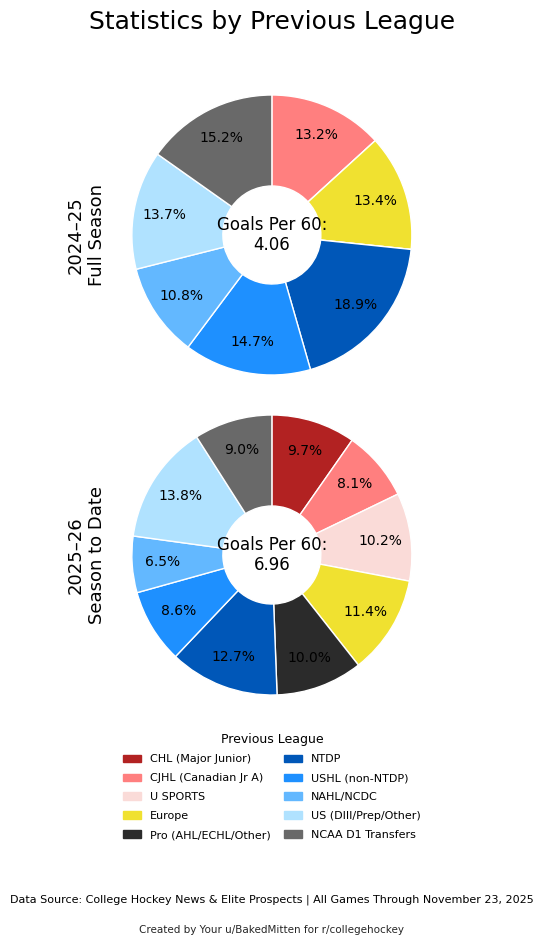

In [216]:
## Call the plot_origin_donuts function to plot Goals per Game by Previous League for 24-25 vs 25-26 YTD
fig = plot_origin_donuts(
    df_prev_agg=agg_24_25_df,
    df_current_agg=agg_df,
    metric="G_per_60min",
    title="Statistics by Previous League",
    # prev_label="Full 2024–25 Season", # Leave Commented to Used Default
    # current_label="2025–26 Season to Date", # Leave Commented to Used Default
    label_mode="percent",
    raw_decimals=2,
    min_pct_for_label=0.05,
    figsize=(10, 10),
    data_source_text=f"Data Source: College Hockey News & Elite Prospects | All Games Through {config.last_game_date}",
    signature_text="Created by Your u/BakedMitten for r/collegehockey",
    center_value_decimals=2,
)
# Show the plot
plt.show()

### Stacked Bar Charts
- not sure if I will be able to do much with these

In [217]:

# Optional: Exo 2 font if you have it
import matplotlib.font_manager as fm

def get_exo2_font(font_path="../../data/Exo_2/data/Exo_2/Exo2-VariableFont_wght.ttf"):
    try:
        font_prop = fm.FontProperties(fname=font_path)
        plt.rcParams["font.family"] = font_prop.get_name()
        return font_prop
    except Exception:
        # silently fall back to default
        return None

# Default Parameters for plots
label_mode="percent",   # options: "percent", "raw", or None
raw_decimals=3,         # number of decimals when label_mode="raw"
min_pct_for_label=0.05  # hide tiny slivers (<5%)


def plot_origin_stacked_stats(
    df: pd.DataFrame,
    bin_color_mapping: dict,
    metrics=("Player_Count", "Games_Played", "G", "A", "Pts", "Shots"),
    normalize=True,
    sort_bins_by="Player_Count",
    figsize=(8, 10),
    title="Roster Construction by Origin (Stacked Stats)",
    subtitle=None,
    footnote="Data source: College Hockey News | Regular Season Only",
    output_path: str | Path | None = None,
    label_mode="percent",      # <-- NEW
    raw_decimals=2,            # <-- NEW
    min_pct_for_label=0.05,    # <-- NEW
):


    ...

    """
    Create a stacked bar where each bar represents a stat (Player_Count, G, etc.)
    and each segment is an origin bin, colored using bin_color_mapping.

    Parameters
    ----------
    df : DataFrame
        Must contain 'Prev_League_Bin' and all metric columns.
    bin_color_mapping : dict
        Mapping from Prev_League_Bin -> color hex.
    metrics : tuple/list of str
        Stat columns to include as separate stacked bars.
    normalize : bool
        If True, each bar sums to 1.0 (100% stacked).
    sort_bins_by : str
        Column used to sort the legend / stacking order (usually Player_Count).
    figsize : tuple
        Figure size in inches (width, height).
    title, subtitle, footnote : str
        Text strings for the plot.
    output_path : str or Path or None
        If provided, saves the figure to this path (PNG recommended).
    """

    # Work on a copy and make sure we only use rows where the metrics exist
    df = df.copy()

    # Make sure all metrics exist
    missing = [m for m in metrics if m not in df.columns]
    if missing:
        raise ValueError(f"Missing metric columns in df: {missing}")

    # Sort bins by some overall importance (e.g. Player_Count)
    if sort_bins_by not in df.columns:
        raise ValueError(f"sort_bins_by='{sort_bins_by}' not in df columns")

    df_sorted = df.sort_values(sort_bins_by, ascending=False)
    df_sorted = df_sorted.reset_index(drop=True)

    # Restrict to bins that appear in the color mapping
    df_sorted = df_sorted[df_sorted["Prev_League_Bin"].isin(bin_color_mapping.keys())]

    if df_sorted.empty:
        raise ValueError("No bins in df match keys in bin_color_mapping")

    # Build base table: index = Prev_League_Bin, columns = metrics
    df_for_plot = df_sorted.set_index("Prev_League_Bin")[list(metrics)]

    # -----------------------------------------------
    # ENFORCE YOUR CUSTOM BIN ORDER (THIS IS THE FIX)
    # -----------------------------------------------
    # Keep only bins that actually appear in the data
    bins_in_plot = [b for b in BIN_ORDER if b in df_for_plot.index]

    if not bins_in_plot:
        raise ValueError("None of the BIN_ORDER entries are present in df_for_plot.index")

    # Reindex df_for_plot to match your order exactly
    df_for_plot = df_for_plot.loc[bins_in_plot]
    # -----------------------------------------------

    # Optional: set Exo 2 as font if available
    exo_font = get_exo2_font()

    # Normalize after reordering
    if normalize:
        col_sums = df_for_plot.sum(axis=0)
        # avoid division-by-zero if any metric column sums to 0
        col_sums = col_sums.replace(0, np.nan)
        df_for_plot = df_for_plot.divide(col_sums, axis=1)

    bins_in_order = df_for_plot.index.tolist()  # stacking order

    x = np.arange(len(metrics))  # one bar per metric
    bottoms = np.zeros(len(metrics))

    fig, ax = plt.subplots(figsize=figsize, dpi=300)

    # Stack each bin across the metrics
    for bin_name in bins_in_order:
        values = df_for_plot.loc[bin_name].values.astype(float)
        color = bin_color_mapping.get(bin_name, "#cccccc")

        # snapshot of current bottoms BEFORE adding this bin (used for label positions)
        segment_bottoms = bottoms.copy()

        ax.bar(
            x,
            values,
            bottom=bottoms,
            color=color,
            edgecolor="white",
            linewidth=0.6,
            label=bin_name,
        )
        # annotate segments
        if label_mode is not None:
            for i, v in enumerate(values):
                if v <= 0:
                    continue

                # percentage of the bar (normalized or not)
                if normalize:
                    pct = v  # already fraction
                else:
                    total = df_for_plot.sum(axis=0)[i]
                    if total == 0:
                        continue
                    pct = v / total

                # skip tiny segments
                if pct < min_pct_for_label:
                    continue

                # y position for centered label
                y_center = segment_bottoms[i] + v / 2.0

                # determine the label text
                if label_mode == "percent":
                    label = f"{pct*100:.0f}%"
                elif label_mode == "raw":
                    label = f"{v:.{raw_decimals}f}"
                else:
                    continue  # label_mode=None → no labels

                ax.text(
                    x[i],
                    y_center,
                    label,
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white",
                    clip_on=True,
                )

        # --- annotate each segment with percentage in the center ---
        # if normalize:  # only makes sense as % when bars sum to 1
        #     for i, v in enumerate(values):
        #         if v <= 0:
        #             continue
        #         pct = v  # because normalized, v is already a fraction of the bar
        #         if pct < min_pct_for_label:
        #             continue  # skip tiny slivers

        #         y_center = segment_bottoms[i] + v / 2.0
        #         ax.text(
        #             x[i],
        #             y_center,
        #             f"{pct*100:.0f}%",
        #             ha="center",
        #             va="center",
        #             fontsize=7,
        #             color="white",
        #             clip_on=True,
        #         )
        # else:
        #     # If not normalized, you can still show share per metric column
        #     col_sums = df_for_plot.sum(axis=0)
        #     for i, v in enumerate(values):
        #         if v <= 0:
        #             continue
        #         if col_sums[i] == 0:
        #             continue
        #         pct = v / col_sums[i]
        #         if pct < min_pct_for_label:
        #             continue

        #         y_center = segment_bottoms[i] + v / 2.0
        #         ax.text(
        #             x[i],
        #             y_center,
        #             f"{pct*100:.0f}%",
        #             ha="center",
        #             va="center",
        #             fontsize=7,
        #             color="white",
        #             clip_on=True,
        #         )
        # -----------------------------------------------------------

        bottoms += values

 

    # x-axis labels = metrics, clean them up
    clean_metric_labels = [
        m.replace("_per_60min", "/60").replace("_", " ").title().replace("Pts", "Points")
        for m in metrics
    ]
    ax.set_xticks(x)
    ax.set_xticklabels(clean_metric_labels, rotation=0, ha="center")

    # y-axis formatting
    if normalize:
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y*100)}%"))
        ax.set_ylabel("Share of Total (All Origins)", fontsize=11)
    else:
        ax.set_ylabel("Total Value", fontsize=11)

    # Grid + spines for your usual clean look
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.4)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # Title + subtitle
    if title:
        ax.set_title(title, fontsize=16, pad=10)
    if subtitle:
        ax.text(
            0.5,
            1.02,
            subtitle,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=11,
            alpha=0.8,
        )


    # give enough bottom margin for the legend
    fig.subplots_adjust(bottom=0.18)

    fig.legend(
        handles=handles,
        title="Previous League",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=cols,
        frameon=False,
        fontsize=8,
        title_fontsize=9,
        handlelength=1.6,
        columnspacing=1.2,
        labelspacing=0.8
    )


    # Footnote
    if footnote:
        ax.text(
            0.5,
            -0.13,
            footnote,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=8,
            alpha=0.7,
        )

    fig.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved stacked origin plot to: {output_path}")

    return fig, ax

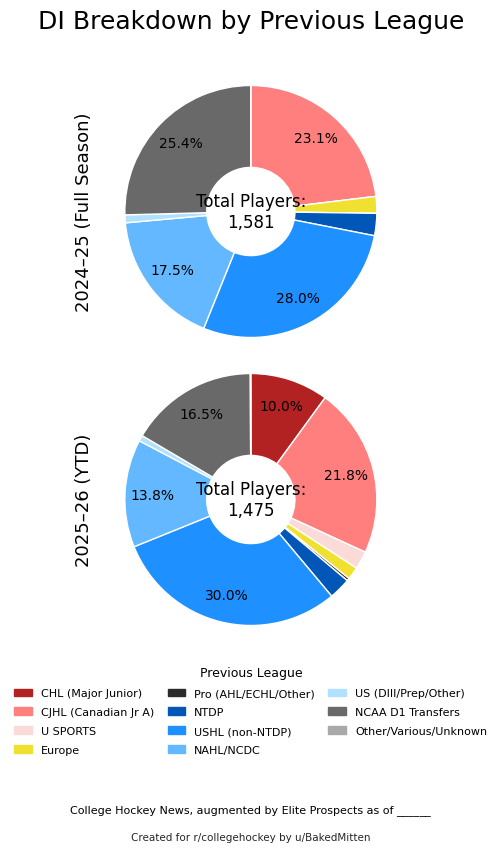

In [232]:
# font_prop from your helper
font_prop = get_exo2_font()

fig = plot_origin_donuts(
    df_prev_agg=agg_24_25_df,
    df_current_agg=agg_df,
    metric="Player_Count",
    title="DI Breakdown by Previous League",
    prev_label="2024–25 (Full Season)",
    current_label="2025–26 (YTD)",
    label_mode="percent",             # or "raw", or None
    raw_decimals=2,
    min_pct_for_label=0.03,
    font_prop=font_prop,
    data_source_text="College Hockey News, augmented by Elite Prospects as of ______",
    signature_text="Created for r/collegehockey by u/BakedMitten",
    figsize=(9, 9),
    center_value_decimals=2,
)

fig.savefig("origin_donuts_G.png", dpi=300, bbox_inches="tight")
plt.show()


In [219]:
agg_df.head(11)

,Prev_League_Bin,Player_Count,Games_Played,Avg_Games Played,G,A,Pts,PlusMinus,Shots,TOI_sec,...,TOI_sec_per_game,PIM_per_game,Games_Played_per_60min,G_per_60min,A_per_60min,Pts_per_60min,PlusMinus_per_60min,Shots_per_60min,TOI_sec_per_60min,PIM_per_60min
0,NTDP,41,507,12.365854,123,168,291,42,944,501782,...,989.708087,0.867850,3.637436,0.882455,1.205304,2.087759,0.301326,6.772662,3600.0,3.156749
1,USHL (non‑NTDP),442,4753,10.753394,743,1319,2062,224,7669,4480131,...,942.590154,0.546602,3.819263,0.597036,1.059880,1.656916,0.179995,6.162409,3600.0,2.087618
2,NAHL/NCDC,204,1745,8.553922,183,339,522,-250,2241,1453579,...,832.996562,0.483668,4.321747,0.453226,0.839583,1.292809,-0.619161,5.550163,3600.0,2.090289
3,US (DIII/Prep/Other),11,109,9.909091,28,27,55,6,216,104940,...,962.752294,0.660550,3.739280,0.960549,0.926244,1.886792,0.205832,7.409949,3600.0,2.469983
4,CHL (Major Junior),148,1670,11.283784,290,464,754,-53,2879,1544309,...,924.735928,0.640120,3.893003,0.676031,1.081649,1.757679,-0.123550,6.711351,3600.0,2.491988
5,CJHL (Canadian Jr A),322,2995,9.301242,403,687,1090,-120,4172,2564893,...,856.391653,0.477796,4.203684,0.565638,0.964251,1.529888,-0.168428,5.855683,3600.0,2.008505
6,U SPORTS,34,371,10.911765,70,124,194,-17,607,356445,...,960.768194,0.770889,3.747002,0.706981,1.252367,1.959349,-0.171695,6.130539,3600.0,2.888524
7,Europe,24,231,9.625000,44,62,106,11,314,199491,...,863.597403,0.454545,4.168609,0.794021,1.118847,1.912868,0.198505,5.666421,3600.0,1.894822
8,NCAA D1 Transfers,243,2814,11.580247,481,801,1282,-36,4796,2754727,...,978.936389,0.577470,3.677461,0.628592,1.046782,1.675375,-0.047046,6.267627,3600.0,2.123622
9,Pro (AHL/ECHL/Other),5,62,12.400000,14,27,41,12,106,72312,...,1166.322581,1.048387,3.086625,0.696980,1.344175,2.041155,0.597411,5.277132,3600.0,3.235977


In [220]:
# origin_df = agg_df.copy()

# metrics = ("G_per_game", "A_per_game")

# fig, ax = plot_origin_stacked_stats(
#     origin_df,
#     bin_color_mapping,
#     metrics=metrics,
#     label_mode="raw",
#     raw_decimals=2,
#     min_pct_for_label=0.05,
#     title="Roster Construction by Origin (Stacked Stats)",
#     subtitle="2023-24 NCAA Season",
#     footnote="Data source: College Hockey News | Regular Season Only",
#     output_path="../../TEMP/roster_construction_by_origin_stacked_stats.png"
# )

In [221]:
# ### Call The New Viz Function to create stacked bar plot of origin stats - This is by Player

# origin_df = agg_df.copy()

# metrics = ("G_per_player", "A_per_player", "Pts_per_player", "Shots_per_player", "TOI_sec_per_player", "PIM_per_player")

# fig, ax = plot_origin_stacked_stats(
#     df=origin_df,
#     bin_color_mapping=bin_color_mapping,
#     metrics=metrics,
#     normalize=True,  # 100% stacked (shares)
#     sort_bins_by="Player_Count",
#     title="How DI Rosters Are Built by Origin",
#     # subtitle="Share of players, games, goals, assists, points, and shots by previous team/league",
#     footnote="Data source: College Hockey News | Includes all games in current season",
#     output_path="plots/origin_stacked_stats.png",
# )


In [222]:
# # Stacked bar with per game stats
# metrics_per_game = ("G_per_game", "A_per_game", "Pts_per_game",  "PIM_per_game")

# fig, ax = plot_origin_stacked_stats(
#     df=origin_df,
#     bin_color_mapping=bin_color_mapping,
#     metrics=metrics_per_game,
#     normalize=True,  # 100% stacked (shares)
#     sort_bins_by="Player_Count",
#     title="How DI Rosters Are Built by Origin (Per Game)",
#     footnote="Data source: College Hockey News | Includes all games in current season",
#     output_path="plots/origin_stacked_stats_per_game.png",
# )

In [223]:
# metrics_raw = ("G_per_game", "A_per_game")

# ### Plot with raw count (not normalized)
# fig, ax = plot_origin_stacked_stats(
#     df=origin_df,
#     label_mode="raw",
#     bin_color_mapping=bin_color_mapping,
#     raw_decimals=3,
#     metrics=metrics_raw,
#     normalize=False,  # raw counts
#     sort_bins_by="Player_Count",
#     title="How DI Rosters Are Built by Origin (Raw Counts)",
#     footnote="Data source: College Hockey News | Includes all games in current season",
#     output_path="plots/origin_stacked_stats_raw_counts.png",
# )

## Bin By Country

In [224]:
### Do The Aggrigation by Home Country
country_agg_stats = {
    "Games_Played": "sum",
    "G": "sum",
    "A": "sum",
    "Pts": "sum",
    "PlusMinus": "sum",
    "Shots": "sum",
    "TOI_sec": "sum",
    "PIM": "sum",
}
country_agg_df = merged_df.groupby("Country").agg(country_agg_stats).reset_index()
print(country_agg_df.head(20))

## Get count of players in each Country and calculate per player averages
country_player_counts = (df["Country"]
                    .value_counts(dropna=False)
                    .fillna(0).astype(int))
# print("Player Counts by Country")
# print(country_player_counts.reset_index().rename(columns={"index":"Country","Country":" Count"}))

           Country  Games_Played    G     A   Pts  PlusMinus  Shots  TOI_sec  \
0          Austria            33    8    15    23          0     54    32523   
1          Belarus            16    5     4     9         -2     16    11815   
2           Canada          5617  919  1546  2465       -127   9044  5148706   
3   Cayman Islands            15    0     8     8         -5     21    15879   
4          Croatia             9    1     1     2          3     19     5169   
5   Czech Republic            75   19    25    44        -10    155    79196   
6          Czechia            13    1     2     3        -10     25    12886   
7          Finland           203   35    49    84          3    287   176115   
8          Germany            13    2     4     6          0     28    12514   
9    Great Britain            10    1     1     2          1     11     7116   
10         Hungary            11    1     2     3          3      9    10236   
11           Italy            14    0   

In [225]:
## Calculate per player averages for each aggregated stat by Country
country_player_counts = country_player_counts.reindex(country_agg_df["Country"])
for stat in country_agg_stats.keys():
    country_agg_df[stat + "_per_player"] = country_agg_df[stat] / country_player_counts.values

# Calculate per game averages for each aggregated stat by Country
for stat in country_agg_stats.keys():
    country_agg_df[stat + "_per_game_played"] = country_agg_df[stat] / country_agg_df["Games_Played"]

## Calculate rate stats per 60 minutes for each aggregated stat by Country
for stat in country_agg_stats.keys():
    country_agg_df[stat + "_per_60min"] = (country_agg_df[stat] / country_agg_df["TOI_sec"]) * 3600

country_agg_df.info()
country_agg_df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       23 non-null     object 
 1   Games_Played                  23 non-null     int64  
 2   G                             23 non-null     int64  
 3   A                             23 non-null     int64  
 4   Pts                           23 non-null     int64  
 5   PlusMinus                     23 non-null     int64  
 6   Shots                         23 non-null     int64  
 7   TOI_sec                       23 non-null     int64  
 8   PIM                           23 non-null     int64  
 9   Games_Played_per_player       23 non-null     float64
 10  G_per_player                  23 non-null     float64
 11  A_per_player                  23 non-null     float64
 12  Pts_per_player                23 non-null     float64
 13  PlusMin

,Country,Games_Played,G,A,Pts,PlusMinus,Shots,TOI_sec,PIM,Games_Played_per_player,...,TOI_sec_per_game_played,PIM_per_game_played,Games_Played_per_60min,G_per_60min,A_per_60min,Pts_per_60min,PlusMinus_per_60min,Shots_per_60min,TOI_sec_per_60min,PIM_per_60min
0,Austria,33,8,15,23,0,54,32523,10,11.000000,...,985.545455,0.303030,3.652800,0.885527,1.660363,2.545891,0.000000,5.977308,3600.0,1.106909
1,Belarus,16,5,4,9,-2,16,11815,4,8.000000,...,738.437500,0.250000,4.875159,1.523487,1.218790,2.742277,-0.609395,4.875159,3600.0,1.218790
2,Canada,5617,919,1546,2465,-127,9044,5148706,3353,10.382625,...,916.629161,0.596938,3.927433,0.642569,1.080971,1.723540,-0.088799,6.323608,3600.0,2.344434
3,Cayman Islands,15,0,8,8,-5,21,15879,8,7.500000,...,1058.600000,0.533333,3.400718,0.000000,1.813716,1.813716,-1.133573,4.761005,3600.0,1.813716
4,Croatia,9,1,1,2,3,19,5169,2,9.000000,...,574.333333,0.222222,6.268137,0.696460,0.696460,1.392919,2.089379,13.232734,3600.0,1.392919
5,Czech Republic,75,19,25,44,-10,155,79196,44,12.500000,...,1055.946667,0.586667,3.409263,0.863680,1.136421,2.000101,-0.454568,7.045810,3600.0,2.000101
6,Czechia,13,1,2,3,-10,25,12886,2,13.000000,...,991.230769,0.153846,3.631849,0.279373,0.558746,0.838119,-2.793730,6.984324,3600.0,0.558746
7,Finland,203,35,49,84,3,287,176115,85,9.666667,...,867.561576,0.418719,4.149561,0.715442,1.001618,1.717060,0.061324,5.866621,3600.0,1.737501
8,Germany,13,2,4,6,0,28,12514,4,13.000000,...,962.615385,0.307692,3.739811,0.575356,1.150711,1.726067,0.000000,8.054978,3600.0,1.150711
9,Great Britain,10,1,1,2,1,11,7116,8,10.000000,...,711.600000,0.800000,5.059022,0.505902,0.505902,1.011804,0.505902,5.564924,3600.0,4.047218


## Bin By State / Province

In [226]:
## Examine the State_Province column value counts
state_prov_counts = merged_df['State_Province'].value_counts()
print("State/Province Value Counts")
print(state_prov_counts)

State/Province Value Counts
State_Province
Minnesota           185
Ontario             180
British Columbia    107
Alberta              99
New York             84
                   ... 
Oklahoma              1
JPN                   1
Italy                 1
Scotland              1
RUS                   1
Name: count, Length: 69, dtype: int64


In [227]:

## Filter out any rows that don't have USA or CAN in the Country column

# print length of merged_df before filtering
print("Merged DataFrame shape before filtering for USA/CAN:", merged_df.shape)
us_can_df = merged_df[(merged_df["Country"] == "USA") | (merged_df["Country"] == "Canada")]

# print length of us_can_df after filtering
print("Filtered DataFrame shape for USA/CAN:", us_can_df.shape)

# Print summary of State_Province values in us_can_df
print("USA/CAN DataFrame State/Province Value Counts")
# USA / Canada Country Value Counts
print(us_can_df['Country'].value_counts())
# State Province Value Counts
print(us_can_df['State_Province'].value_counts())

# Check State Province values of rows filtered out
# filtered_out_df = merged_df[~merged_df.index.isin(us_can_df.index)]
# print("Filtered Out DataFrame State/Province Value Counts")
# print(filtered_out_df['State_Province'].value_counts())


Merged DataFrame shape before filtering for USA/CAN: (1475, 32)
Filtered DataFrame shape for USA/CAN: (1358, 32)
USA/CAN DataFrame State/Province Value Counts
Country
USA       817
Canada    541
Name: count, dtype: int64
State_Province
Minnesota                    185
Ontario                      180
British Columbia             107
Alberta                       99
New York                      84
Massachusetts                 73
Michigan                      70
Quebec                        67
Illinois                      55
California                    45
New Jersey                    38
Saskatchewan                  35
Pennsylvania                  30
Manitoba                      27
Wisconsin                     26
Connecticut                   26
New Hampshire                 14
North Dakota                  14
Colorado                      14
Missouri                      13
Ohio                          13
Alaska                        12
Maryland                      12
India

In [228]:
### Group and aggregate stats by State_Province for USA and CAN players
state_prov_agg_stats = {
    "Games_Played": "sum",
    "G": "sum",
    "A": "sum",
    "Pts": "sum",
    "PlusMinus": "sum",
    "Shots": "sum",
    "TOI_sec": "sum",
    "PIM": "sum",
}

state_prov_agg_df = us_can_df.groupby("State_Province").agg(state_prov_agg_stats).reset_index()
print(state_prov_agg_df.head(20))

## Get count of players in each State_Province and calculate per player averages
state_prov_player_counts = (us_can_df["State_Province"]
                    .value_counts(dropna=False)
                    .fillna(0).astype(int))
print("Player Counts by State/Province")
print(state_prov_player_counts.reset_index().rename(columns={"index":"State/Province","State_Province":" Count"}))

### Divide aggregated stats by player counts to get per player averages by State_Province
state_prov_player_counts = state_prov_player_counts.reindex(state_prov_agg_df["State_Province"])
for stat in state_prov_agg_stats.keys():
    state_prov_agg_df[stat + "_per_player"] = state_prov_agg_df[stat] / state_prov_player_counts.values

## Calculate rate stats per 60 minutes for each aggregated stat by State_Province
for stat in state_prov_agg_stats.keys():
    state_prov_agg_df[stat + "_per_60min"] = (state_prov_agg_df[stat] / state_prov_agg_df["TOI_sec"]) * 3600

# Calculate per game averages for each aggregated stat by State_Province
for stat in state_prov_agg_stats.keys():
    state_prov_agg_df[stat + "_per_player_per_game_played"] = state_prov_agg_df[stat] / state_prov_agg_df["Games_Played"]
# state_prov_agg_df.info()
# state_prov_agg_df.head(20)

      State_Province  Games_Played    G    A  Pts  PlusMinus  Shots  TOI_sec  \
0             Alaska           125   20   36   56        -17    229   122940   
1            Alberta          1049  157  257  414        -52   1545   932713   
2            Arizona           118   13   37   50          4    134   103153   
3   British Columbia          1113  158  294  452        -30   1724  1007018   
4         California           416   66  106  172          4    613   353565   
5           Colorado           121    8   17   25         -1    127   103215   
6        Connecticut           244   32   57   89         28    403   214562   
7           Delaware            12    2    4    6          3     10     8710   
8            Florida           116   23   41   64         -5    199   111350   
9            Georgia            69    6   17   23          3     92    53375   
10             Idaho            12    1    3    4         -1     11    17404   
11          Illinois           619   84 

## MAKE A MAP/S FOR REDACTED CHARTS ON REDDIT

In [229]:
# # Check path of shapefile

# shapefile_path = "../../data/vault/10m_state_province_file.shp"

# # try to load file
# with 


In [230]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path



def plot_state_prov_choropleth(
    state_prov_agg_df: pd.DataFrame,
    metric: str = "G",                     # or "Pts"
    shapefile_path: str = "..\\..\\data\\vault\\state_province_geo\\ne_110m_admin_1_states_provinces.shp",
    output_path: str | Path = "state_prov_map_G.png",
    title: str | None = None,
    cmap: str = "YlGnBu",                  # nice smooth gradient
    dpi: int = 300
):
    """
    Plot a static choropleth map of US states + Canadian provinces using
    state_prov_agg_df, which must have columns:
        - 'State_Province'
        - the chosen metric (e.g. 'G' or 'Pts')
    """

    # --- load the shapefile ---
    admin1 = gpd.read_file(shapefile_path)

    # Natural Earth usually has both 'name' and 'name_en'
    # After admin1 = gpd.read_file(shapefile_path)

    # See what columns you have (optional, but handy):
    print("Shapefile columns:", admin1.columns.tolist())

    # Try a few common field names
    candidate_cols = ["name_en", "name", "name_1", "NAME_1", "state_name", "STATE_NAME"]
    name_col = None
    for col in candidate_cols:
        if col in admin1.columns:
            name_col = col
            break

    if name_col is None:
        raise ValueError(
            "Could not find a suitable name column in shapefile. "
            "Available columns are: "
            + ", ".join(admin1.columns.astype(str))
        )

    admin1["region_name"] = admin1[name_col]

    

    # Keep only USA + Canada to match your table
    mask = admin1["admin"].isin(["United States of America", "Canada"])
    regions = admin1.loc[mask].copy()

    # --- join your data onto the geometry ---
    # Make sure the key column is string
    state_prov_agg_df = state_prov_agg_df.copy()
    state_prov_agg_df["State_Province"] = state_prov_agg_df["State_Province"].astype(str)

    merged = regions.merge(
        state_prov_agg_df,
        left_on="region_name",
        right_on="State_Province",
        how="left",
        validate="1:1"
    )

    if metric not in merged.columns:
        raise ValueError(f"Metric '{metric}' is not a column in the dataframe.")

    # --- plotting ---
    fig, ax = plt.subplots(figsize=(8, 10))  # tweak for aspect/Reddit

    # Blank-ish style: no axes, white background
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Draw boundaries lightly so it's minimalist
    merged.boundary.plot(ax=ax, linewidth=0.3, color="lightgrey")

    # Choropleth fill
    merged.plot(
        column=metric,
        ax=ax,
        cmap=cmap,
        linewidth=0.4,
        edgecolor="black",
        legend=True,
        legend_kwds={
            "label": metric,
            "shrink": 0.5,
            "orientation": "vertical"
        },
        missing_kwds={
            "color": "white",
            "edgecolor": "lightgrey",
            "hatch": "///",
            "label": "No data"
        }
    )

    # Nicely centered, mostly-blank map
    ax.set_axis_off()
    ax.set_aspect("equal")

    if title is None:
        title = f"{metric} by State / Province (College Hockey)"
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)

    # Optional subtitle / data source
    # ax.text(0.5, 0.03, "Data: Your College Hockey DB",
    #         transform=fig.transFigure, ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    output_path = Path(output_path)
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    # plt.close(fig)
    # Show the plot
    plt.show()

    print(f"Map saved to: {output_path}")



## Call the function to plot goals by state/province
plot_state_prov_choropleth(
    state_prov_agg_df=state_prov_agg_df,
    metric="G",
    shapefile_path="../../data/vault/10m_state_province_file.shp",
    output_path=plot_folder / "state_prov_map_G.png",
    title="Goals by State / Province (College Hockey)",
    cmap="YlGnBu",
    dpi=300
)